# implementing angle sweep into grating transmittance plot

## Import

In [8]:
import math
import cmath
import numpy as np

import matplotlib.pyplot as plt

import meep as mp
from meep import materials

import os

## Routine

In [3]:
def sellmeier(sigma, omega, wavelength):
    numerator = sigma * np.square(wavelength)
    denominator = np.square(wavelength) - np.power(omega, -2)
    coeff = numerator / denominator
    
    return coeff

In [ ]:
def transmittance(ppx, ppy, pr, ph, angle_deg, wl):
    resolution = 50 # fdtd grid resolution

    theta_r = math.radians(angle_deg) # convert angle to radians

    fcen = 1/wl # source center wavelength
    df = 0.05 * fcen # source bandwidth

    dpml = 1 # perfectly matched layer thickness
    dsub = 5 * ph # thickness of glass below PhC
    dtop = 5 * ph # thickness of glass above PhC

    # cell dimensions
    sx = ppx 
    sy = ppy
    sz = dpml + dsub + ph + dtop + dpml

    cell_size = mp.Vector3(sx, sy, sz)

    # cell Z boundary
    pml_layers = [mp.PML(thickness=dpml, direction=mp.Z)]

    # calculations for index of the glass at target wavelength
    eps_fq = (
        1 + 
        sellmeier(
            omega = materials.fused_quartz_frq1, 
            sigma = materials.fused_quartz_sig1, 
            wavelength = wl
        ) + 
        sellmeier(
            omega = materials.fused_quartz_frq2, 
            sigma = materials.fused_quartz_sig2, 
            wavelength = wl
        ) + 
        sellmeier(
            omega = materials.fused_quartz_frq3, 
            sigma = materials.fused_quartz_sig3, 
            wavelength = wl
        )
    )

    index_fq = math.sqrt(eps_fq) # permittivity to index
            

    k_point = mp.Vector3(0, 0, fcen * index_fq).rotate(mp.Vector3(1, 0, 0), theta_r)

    src_pt = mp.Vector3(0, 0, 0.5 * sz - 0.5 * (dpml + dtop + ph))
    ref_mon_pt = mp.Vector3(0, 0, 1.1 * ph)
    trans_mon_pt = mp.Vector3(0, 0, -0.5 * sz + 0.5 * (dpml + dsub))

    geometry = [
        mp.Block(
            material = materials.fused_quartz, 
            size = mp.Vector3(mp.inf, mp.inf, sz), 
            center = mp.Vector3()
        ), 
        mp.Cylinder( 
            material = materials.aSi, 
            height = ph, 
            radius= pr, 
            axis = mp.Vector3(0, 0, 1), 
            center = mp.Vector3(0, 0, 0.5 * ph)
        )
    ]

    def pw_amp(k, x0):
        def _pw_amp(x):
            return cmath.exp(1j * 2 * math.pi * k.dot(x + x0))
        
        return _pw_amp

    sources = [
        mp.Source(
            mp.ContinuousSource(fcen, fwidth = df), 
            component = mp.Ex, 
            center = src_pt,
            size = mp.Vector3(sx, sy, 0), 
            amp_func=pw_amp(k_point, src_pt)
        )
    ]

    symmetries = [mp.Mirror(mp.Y)]

    sim = mp.Simulation(
        resolution=resolution,
        cell_size=cell_size,
        boundary_layers=pml_layers,
        k_point=k_point,
        geometry=geometry,
        sources=sources, 
        symmetries = symmetries
    )

    baseline_flux = sim.add_flux(
        fcen, 
        0, 
        1, 
        mp.FluxRegion(center = ref_mon_pt, size = mp.Vector3(sx, sy, 0))
    )
    trans_flux = sim.add_flux(
        fcen, 
        0, 
        1, 
        mp.FluxRegion(center = trans_mon_pt, size = mp.Vector3(sx, sy, 0))
    )
    
    sim.run(until = 50)

    b_flux = mp.get_fluxes(baseline_flux)
    t_flux = mp.get_fluxes(trans_flux)
    Tflux = t_flux[0]/b_flux[0]

    return Tflux
    
            

## Dispersion plot

In [18]:
wl_ = np.linspace(1.0, 1.4, 20)
angle_ = np.linspace(0, 20, 20)

wl = []
angle = []
T = []

for i in range(len(wl_)):
    for j in range(len(angle_)):
        print(wl_[i], ", ", angle_[j], ", ", i * len(angle_) + j,  "/", len(wl_) * len(angle_))
        wl.append(wl_[i])
        angle.append(angle_[j])
        T.append(
            transmittance(ppx = 0.6, 
                          ppy = 0.6, 
                          pr = 0.140, 
                          ph = 0.440, 
                          angle_deg = angle_[j], 
                          wl = wl_[i]
            )
        )

1.0 ,  0.0 ,  0 / 400
-----------
Initializing structure...
Halving computational cell along direction y
time for choose_chunkdivision = 0.0014 s
Working in 3D dimensions.
Computational cell is 0.6 x 0.6 x 6.84 with resolution 50
     block, center = (0,0,0)
          size (1e+20,1e+20,6.84)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,0,0.22)
          radius 0.14, height 0.44, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.109,3.109,3.109)
time for set_epsilon = 0.203322 s
lorentzian susceptibility: frequency=3.16976, gamma=1.54858
lorentzian susceptibility: frequency=0.101049, gamma=0
lorentzian susceptibility: frequency=8.60279, gamma=0
lorentzian susceptibility: frequency=14.619, gamma=0
-----------
Meep: using complex fields.


/Applications/anaconda3/envs/ImgDiffP/lib/python3.13/site-packages/meep/simulation.py:1664: RuntimeWarning: Note: your sources include frequencies outside the range of validity of the material models. This is fine as long as you eventually only look at outputs (fluxes, resonant modes, etc.) at valid frequencies.
  warnings.warn(warn_src, RuntimeWarning)
/Applications/anaconda3/envs/ImgDiffP/lib/python3.13/site-packages/meep/simulation.py:1668: RuntimeWarning: DFT frequency 1.0 is out of material's range of 1.2048192771084338-4.761904761904762
  warnings.warn(


Meep progress: 5.34/50.0 = 10.7% done in 4.0s, 33.5s to go
on time step 534 (time=5.34), 0.00749318 s/step
Meep progress: 11.22/50.0 = 22.4% done in 8.0s, 27.7s to go
on time step 1123 (time=11.23), 0.00680254 s/step
Meep progress: 16.830000000000002/50.0 = 33.7% done in 12.0s, 23.7s to go
on time step 1684 (time=16.84), 0.00714035 s/step
Meep progress: 22.13/50.0 = 44.3% done in 16.0s, 20.2s to go
on time step 2214 (time=22.14), 0.00755854 s/step
Meep progress: 27.47/50.0 = 54.9% done in 20.0s, 16.4s to go
on time step 2749 (time=27.49), 0.00749002 s/step
Meep progress: 32.8/50.0 = 65.6% done in 24.0s, 12.6s to go
on time step 3282 (time=32.82), 0.00750547 s/step
Meep progress: 38.11/50.0 = 76.2% done in 28.0s, 8.7s to go
on time step 3813 (time=38.13), 0.00753775 s/step
Meep progress: 43.4/50.0 = 86.8% done in 32.0s, 4.9s to go
on time step 4343 (time=43.43), 0.00756202 s/step
Meep progress: 48.64/50.0 = 97.3% done in 36.0s, 1.0s to go
on time step 4867 (time=48.67), 0.00763576 s/ste

/Applications/anaconda3/envs/ImgDiffP/lib/python3.13/site-packages/meep/simulation.py:1668: RuntimeWarning: DFT frequency 0.979381443298969 is out of material's range of 1.2048192771084338-4.761904761904762
  warnings.warn(


Meep progress: 3.29/50.0 = 6.6% done in 4.0s, 56.8s to go
on time step 329 (time=3.29), 0.0121623 s/step
Meep progress: 7.05/50.0 = 14.1% done in 8.0s, 48.8s to go
on time step 705 (time=7.05), 0.0106563 s/step
Meep progress: 11.35/50.0 = 22.7% done in 12.0s, 40.9s to go
on time step 1136 (time=11.36), 0.00930052 s/step
Meep progress: 15.66/50.0 = 31.3% done in 16.0s, 35.1s to go
on time step 1567 (time=15.67), 0.0092902 s/step
Meep progress: 20.01/50.0 = 40.0% done in 20.0s, 30.0s to go
on time step 2002 (time=20.02), 0.00920606 s/step
Meep progress: 24.14/50.0 = 48.3% done in 24.0s, 25.7s to go
on time step 2415 (time=24.15), 0.00969145 s/step
Meep progress: 28.1/50.0 = 56.2% done in 28.0s, 21.8s to go
on time step 2811 (time=28.11), 0.0101123 s/step
Meep progress: 32.43/50.0 = 64.9% done in 32.0s, 17.4s to go
on time step 3244 (time=32.44), 0.00924244 s/step
Meep progress: 36.61/50.0 = 73.2% done in 36.0s, 13.2s to go
on time step 3662 (time=36.62), 0.00958058 s/step
Meep progress: 

...

Meep progress: 3.94/50.0 = 7.9% done in 4.0s, 46.9s to go
on time step 394 (time=3.94), 0.0101723 s/step
Meep progress: 8.33/50.0 = 16.7% done in 8.0s, 40.1s to go
on time step 833 (time=8.33), 0.00912432 s/step
Meep progress: 12.77/50.0 = 25.5% done in 12.0s, 35.0s to go
on time step 1277 (time=12.77), 0.00901252 s/step
Meep progress: 17.12/50.0 = 34.2% done in 16.0s, 30.8s to go
on time step 1712 (time=17.12), 0.00920924 s/step
Meep progress: 21.52/50.0 = 43.0% done in 20.0s, 26.5s to go
on time step 2152 (time=21.52), 0.00910664 s/step
Meep progress: 25.89/50.0 = 51.8% done in 24.0s, 22.4s to go
on time step 2589 (time=25.89), 0.00915852 s/step
Meep progress: 30.34/50.0 = 60.7% done in 28.0s, 18.2s to go
on time step 3034 (time=30.34), 0.00899691 s/step
Meep progress: 34.71/50.0 = 69.4% done in 32.0s, 14.1s to go
on time step 3471 (time=34.71), 0.00916095 s/step
Meep progress: 39.14/50.0 = 78.3% done in 36.0s, 10.0s to go
on time step 3914 (time=39.14), 0.00904713 s/step
Meep progre

/Applications/anaconda3/envs/ImgDiffP/lib/python3.13/site-packages/meep/simulation.py:1668: RuntimeWarning: DFT frequency 0.7251908396946566 is out of material's range of 1.2048192771084338-4.761904761904762
  warnings.warn(


Meep progress: 3.96/50.0 = 7.9% done in 4.0s, 46.5s to go
on time step 396 (time=3.96), 0.0101025 s/step
Meep progress: 8.21/50.0 = 16.4% done in 8.0s, 40.9s to go
on time step 821 (time=8.21), 0.00949885 s/step
Meep progress: 11.98/50.0 = 24.0% done in 12.0s, 38.2s to go
on time step 1201 (time=12.01), 0.0105475 s/step
Meep progress: 16.11/50.0 = 32.2% done in 16.0s, 33.7s to go
on time step 1615 (time=16.15), 0.00968191 s/step
Meep progress: 20.080000000000002/50.0 = 40.2% done in 20.0s, 29.9s to go
on time step 2013 (time=20.13), 0.0100702 s/step
Meep progress: 24.12/50.0 = 48.2% done in 24.0s, 25.8s to go
on time step 2416 (time=24.16), 0.00993744 s/step
Meep progress: 27.66/50.0 = 55.3% done in 28.1s, 22.7s to go
on time step 2771 (time=27.71), 0.0112897 s/step
Meep progress: 31.73/50.0 = 63.5% done in 32.1s, 18.5s to go
on time step 3179 (time=31.79), 0.00982475 s/step
Meep progress: 35.730000000000004/50.0 = 71.5% done in 36.1s, 14.4s to go
on time step 3579 (time=35.79), 0.0100

/Applications/anaconda3/envs/ImgDiffP/lib/python3.13/site-packages/meep/simulation.py:1668: RuntimeWarning: DFT frequency 0.7142857142857143 is out of material's range of 1.2048192771084338-4.761904761904762
  warnings.warn(


Meep progress: 3.85/50.0 = 7.7% done in 4.0s, 48.0s to go
on time step 385 (time=3.85), 0.0104034 s/step
Meep progress: 8.15/50.0 = 16.3% done in 8.0s, 41.1s to go
on time step 815 (time=8.15), 0.0093179 s/step
Meep progress: 12.59/50.0 = 25.2% done in 12.0s, 35.7s to go
on time step 1259 (time=12.59), 0.00901526 s/step
Meep progress: 16.990000000000002/50.0 = 34.0% done in 16.0s, 31.1s to go
on time step 1699 (time=16.99), 0.00909155 s/step
Meep progress: 21.35/50.0 = 42.7% done in 20.0s, 26.9s to go
on time step 2135 (time=21.35), 0.0091935 s/step
Meep progress: 25.740000000000002/50.0 = 51.5% done in 24.0s, 22.6s to go
on time step 2574 (time=25.74), 0.00911778 s/step
Meep progress: 30.1/50.0 = 60.2% done in 28.0s, 18.5s to go
on time step 3010 (time=30.1), 0.00917886 s/step
Meep progress: 34.39/50.0 = 68.8% done in 32.0s, 14.5s to go
on time step 3439 (time=34.39), 0.00933896 s/step
Meep progress: 38.77/50.0 = 77.5% done in 36.0s, 10.4s to go
on time step 3877 (time=38.77), 0.00914

In [2]:
import pandas as pd

data = pd.DataFrame(
    {'angle': angle, 
     'wl': wl, 
     'Trans': T
    }
)

data.to_csv("~/out.csv")



NameError: name 'angle' is not defined

## field view

In [12]:
resolution = 50 # fdtd grid resolution

theta_r = math.radians(0) # convert angle to radians

fcen = 1/1.4 # source center wavelength
df = 0.05 * fcen # source bandwidth

dpml = 1 # perfectly matched layer thickness
dsub = 5 * 0.44 # thickness of glass below PhC
dtop = 5 * 0.44 # thickness of glass above PhC

    # cell dimensions
sx = 0.6 
sy = 0.6
sz = dpml + dsub + 0.44 + dtop + dpml

cell_size = mp.Vector3(sx, sy, sz)

    # cell Z boundary
pml_layers = [mp.PML(thickness=dpml, direction=mp.Z)]

    # calculations for index of the glass at target wavelength
eps_fq = (
        1 + 
        sellmeier(
            omega = materials.fused_quartz_frq1, 
            sigma = materials.fused_quartz_sig1, 
            wavelength = 1.2
        ) + 
        sellmeier(
            omega = materials.fused_quartz_frq2, 
            sigma = materials.fused_quartz_sig2, 
            wavelength = 1.2
        ) + 
        sellmeier(
            omega = materials.fused_quartz_frq3, 
            sigma = materials.fused_quartz_sig3, 
            wavelength = 1.2
        )
    )

index_fq = math.sqrt(eps_fq) # permittivity to index
            

k_point = mp.Vector3(0, 0, 0)

src_pt = mp.Vector3(0, 0, 0.5 * sz - 0.5 * (dpml + dtop + 0.44))
ref_mon_pt = mp.Vector3(0, 0, 1.1 * 0.44)
trans_mon_pt = mp.Vector3(0, 0, -0.5 * sz + 0.5 * (dpml + dsub))

geometry = [
        mp.Block(
            material = materials.fused_quartz, 
            size = mp.Vector3(sx, sy, sz), 
            center = mp.Vector3()
        ), 
        mp.Cylinder( 
            material = materials.aSi, 
            height = 0.44, 
            radius= 0.14, 
            axis = mp.Vector3(0, 0, 1), 
            center = mp.Vector3(0, 0, 0.5 * 0.44)
        )
    ]

def pw_amp(k, x0):
        def _pw_amp(x):
            return cmath.exp(1j * 2 * math.pi * k.dot(x + x0))
        
        return _pw_amp

sources = [
        mp.Source(
            mp.ContinuousSource(fcen, fwidth = df), 
            component = mp.Ex, 
            center = src_pt,
            size = mp.Vector3(sx, sy, 0)
        )
    ]

symmetries = []

sim = mp.Simulation(
        resolution=resolution,
        cell_size=cell_size,
        boundary_layers=pml_layers,
        k_point=k_point,
        geometry=geometry,
        sources=sources, 
        symmetries = symmetries
    )

baseline_flux = sim.add_flux(
        fcen, 
        0, 
        1, 
        mp.FluxRegion(center = ref_mon_pt, size = mp.Vector3(sx, sy, 0))
    )
trans_flux = sim.add_flux(
        fcen, 
        0, 
        1, 
        mp.FluxRegion(center = trans_mon_pt, size = mp.Vector3(sx, sy, 0))
    )
    
sim.run(until = 50)

-----------
Initializing structure...
time for choose_chunkdivision = 4.1008e-05 s
Working in 3D dimensions.
Computational cell is 0.6 x 0.6 x 6.84 with resolution 50
     block, center = (0,0,0)
          size (0.6,0.6,6.84)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,0,0.22)
          radius 0.14, height 0.44, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.109,3.109,3.109)
time for set_epsilon = 0.495724 s
lorentzian susceptibility: frequency=3.16976, gamma=1.54858
lorentzian susceptibility: frequency=0.101049, gamma=0
lorentzian susceptibility: frequency=8.60279, gamma=0
lorentzian susceptibility: frequency=14.619, gamma=0
-----------


/Applications/anaconda3/envs/ImgDiff/lib/python3.13/site-packages/meep/simulation.py:1668: RuntimeWarning: DFT frequency 0.7142857142857143 is out of material's range of 1.2048192771084338-4.761904761904762
  warnings.warn(


FloatProgress(value=0.0, description='0% done ', max=50.0)

Meep progress: 5.93/50.0 = 11.9% done in 4.0s, 29.7s to go
on time step 593 (time=5.93), 0.00674705 s/step
Meep progress: 13.14/50.0 = 26.3% done in 8.0s, 22.5s to go
on time step 1314 (time=13.14), 0.00555411 s/step
Meep progress: 20.32/50.0 = 40.6% done in 12.0s, 17.5s to go
on time step 2032 (time=20.32), 0.00557784 s/step
Meep progress: 27.650000000000002/50.0 = 55.3% done in 16.0s, 12.9s to go
on time step 2765 (time=27.65), 0.00546097 s/step
Meep progress: 34.38/50.0 = 68.8% done in 20.0s, 9.1s to go
on time step 3438 (time=34.38), 0.00594832 s/step
Meep progress: 41.660000000000004/50.0 = 83.3% done in 24.0s, 4.8s to go
on time step 4166 (time=41.66), 0.00550126 s/step
Meep progress: 48.800000000000004/50.0 = 97.6% done in 28.0s, 0.7s to go
on time step 4880 (time=48.8), 0.00560297 s/step
run 0 finished at t = 50.0 (5000 timesteps)


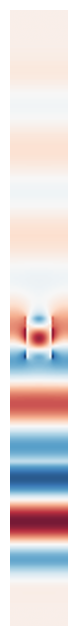

In [13]:
ez_data = sim.get_array(center=mp.Vector3(), size=mp.Vector3(sx, 0, sz), component=mp.Ex)
plt.figure(figsize=(12, 8))
plt.imshow(ez_data.transpose(), interpolation='spline36', cmap='RdBu', alpha=0.9)
plt.axis('off')
plt.show()

ValueError: not enough values to unpack (expected 2, got 1)

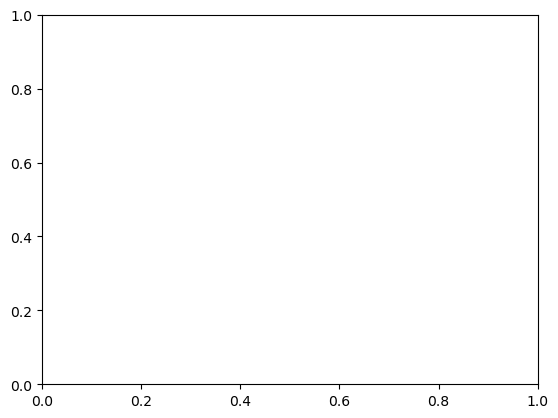

In [ ]:

data = pd.read_csv("out.csv")

fig, ax = plt.subplots()

c = ax.pcolormesh(data["angle"], data["wl"], data["Trans"])

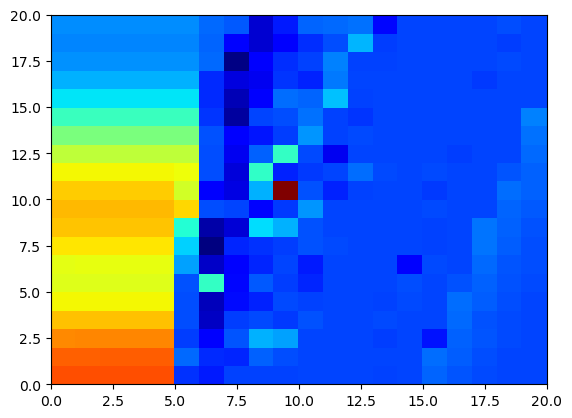

In [ ]:
data_pivot = data.pivot(
    index = "wl", 
    columns = "angle"
)

ooga = data_pivot.to_numpy()

fig, ax = plt.subplots()

c = ax.pcolor(ooga, cmap = "jet")



plt.show()